# 06. Model Explainability using SHAP
### Customer Intelligence Platform for Revenue Retention and CLV Optimization

This notebook runs the SHAP (SHapley Additive exPlanations) engine, generating global feature importance curves, beeswarm plots, and individual customer waterfalls to open the "black box" of our churn and CLV models.

---

## 🎯 Business Objective
A model that cannot explain itself is difficult to trust in business. To build confidence with business owners and marketers, we must explain the **why** behind our predictions.

Our objective here is to:
- Extract global importances using SHAP values for the Churn (XGBoost) and CLV (Random Forest) models.
- Visualize the direction of feature impact (e.g. does higher delay increase or decrease churn risk?).
- Generate local waterfall charts explaining specific customer scores (Low, High, and Borderline risk cases).
- Produce a unified [feature_importance_report.md](file://../reports/feature_importance_report.md) for business presentations.

## 📊 Methodology
1. **Sampling:** SHAP calculations on tree models can be computationally expensive. We compute explainability metrics on a randomized stratified sample of 1,000 customers.
2. **TreeExplainer:** Use SHAP `TreeExplainer` optimized for XGBoost and Random Forest ensembles.
3. **Global Explanations:**
   - Bar plot: Mean absolute SHAP value representing general importance.
   - Beeswarm plot: Illustrates the relationship between feature values (high/low) and SHAP impact (positive/negative).
4. **Local Explanations:** Waterfall plots representing how features push the prediction away from the base value (average outcome) to the final prediction.

### Setup & Imports

In [1]:
import os
import sys
from pathlib import Path

# Add project root to path for local src imports
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import validate_config, REPORTS_DIR, FIGURES_DIR
from src.explainability.shap_explainer import generate_explanations

validate_config()
print("✓ SHAP explainability workflow ready.")

✓ SHAP explainability workflow ready.


### 1. Execute SHAP Explainer Engine
We run the calculation pipeline to generate SHAP values and save visual assets.

In [2]:
generate_explanations()

/Users/asunthalovelin/Documents/P1/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/asunthalovelin/Documents/P1/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.4.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/asunthalovelin/Documents/P1/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator ColumnT

## 🔍 Analysis: Churn Model Drivers (XGBoost)
We inspect the global beeswarm plot to see how features influence churn probabilities.

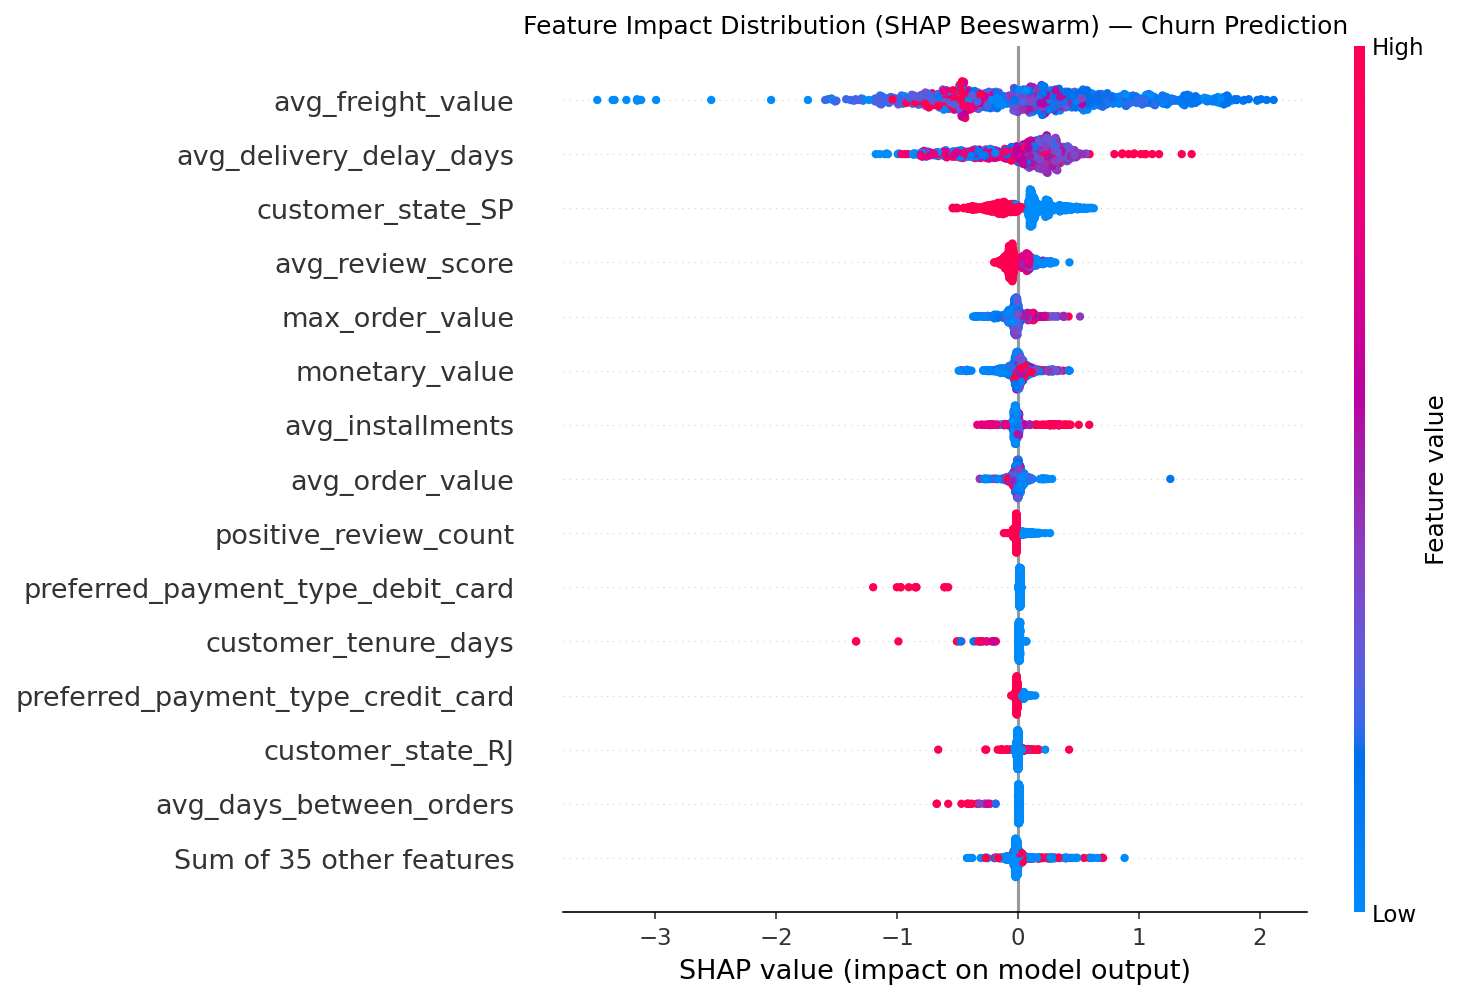

In [3]:
# Display Global Churn Beeswarm Plot
from IPython.display import Image, display
display(Image(filename=str(FIGURES_DIR / 'shap_churn_beeswarm.png')))

### Churn Local Waterfall Case Studies
Let's look at low-risk, borderline, and high-risk customer waterfall paths.

=== Low Churn Risk Case Waterfall ===


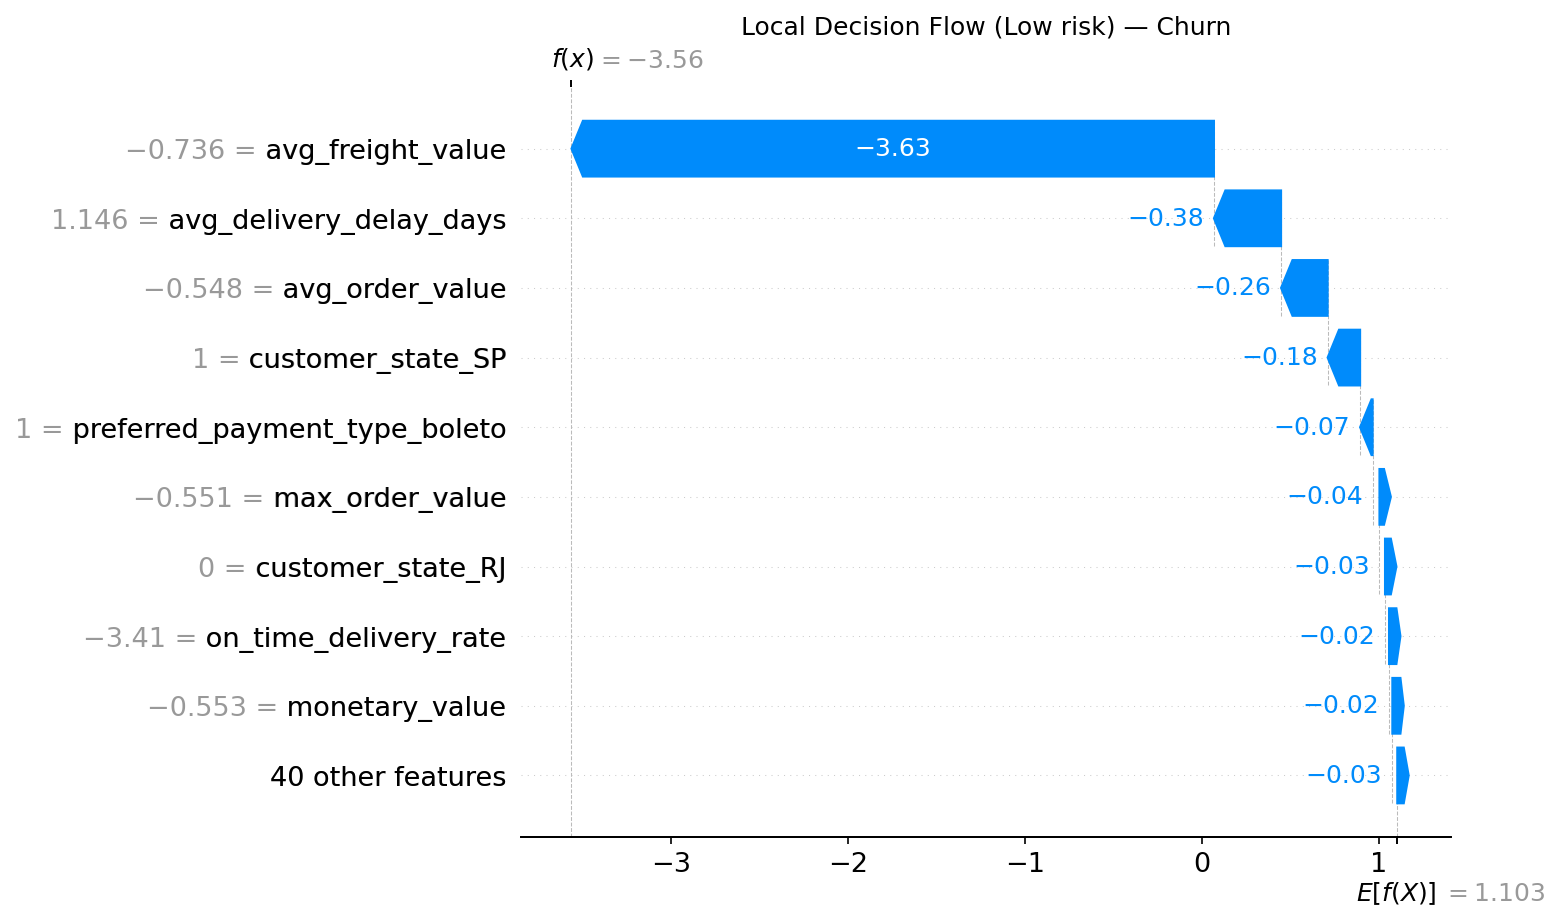

=== Borderline Churn Risk Case Waterfall ===


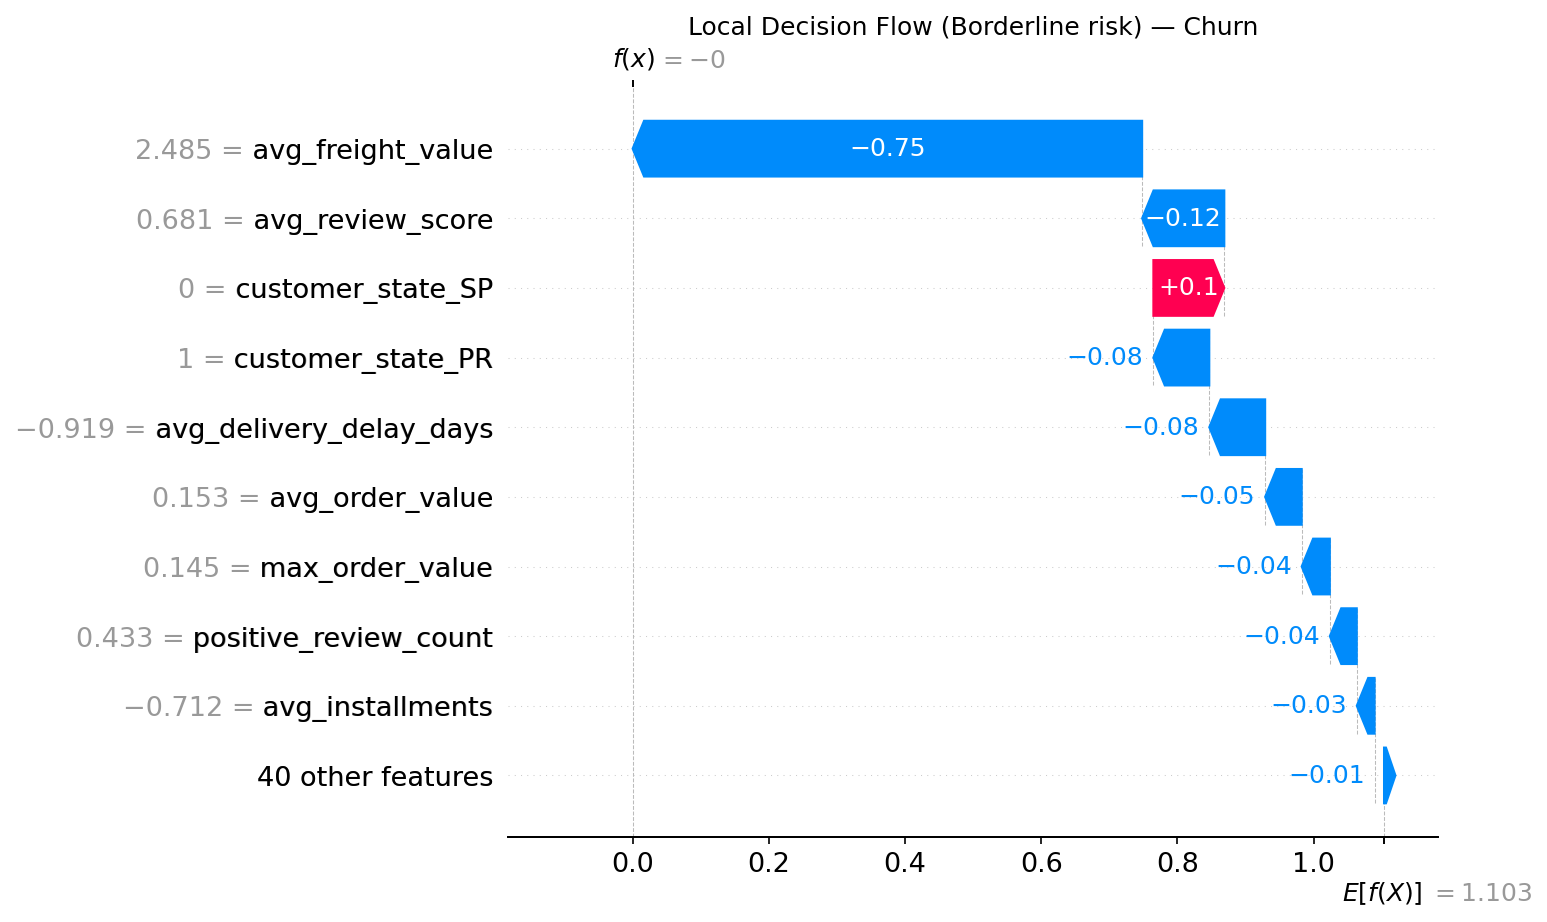

=== High Churn Risk Case Waterfall ===


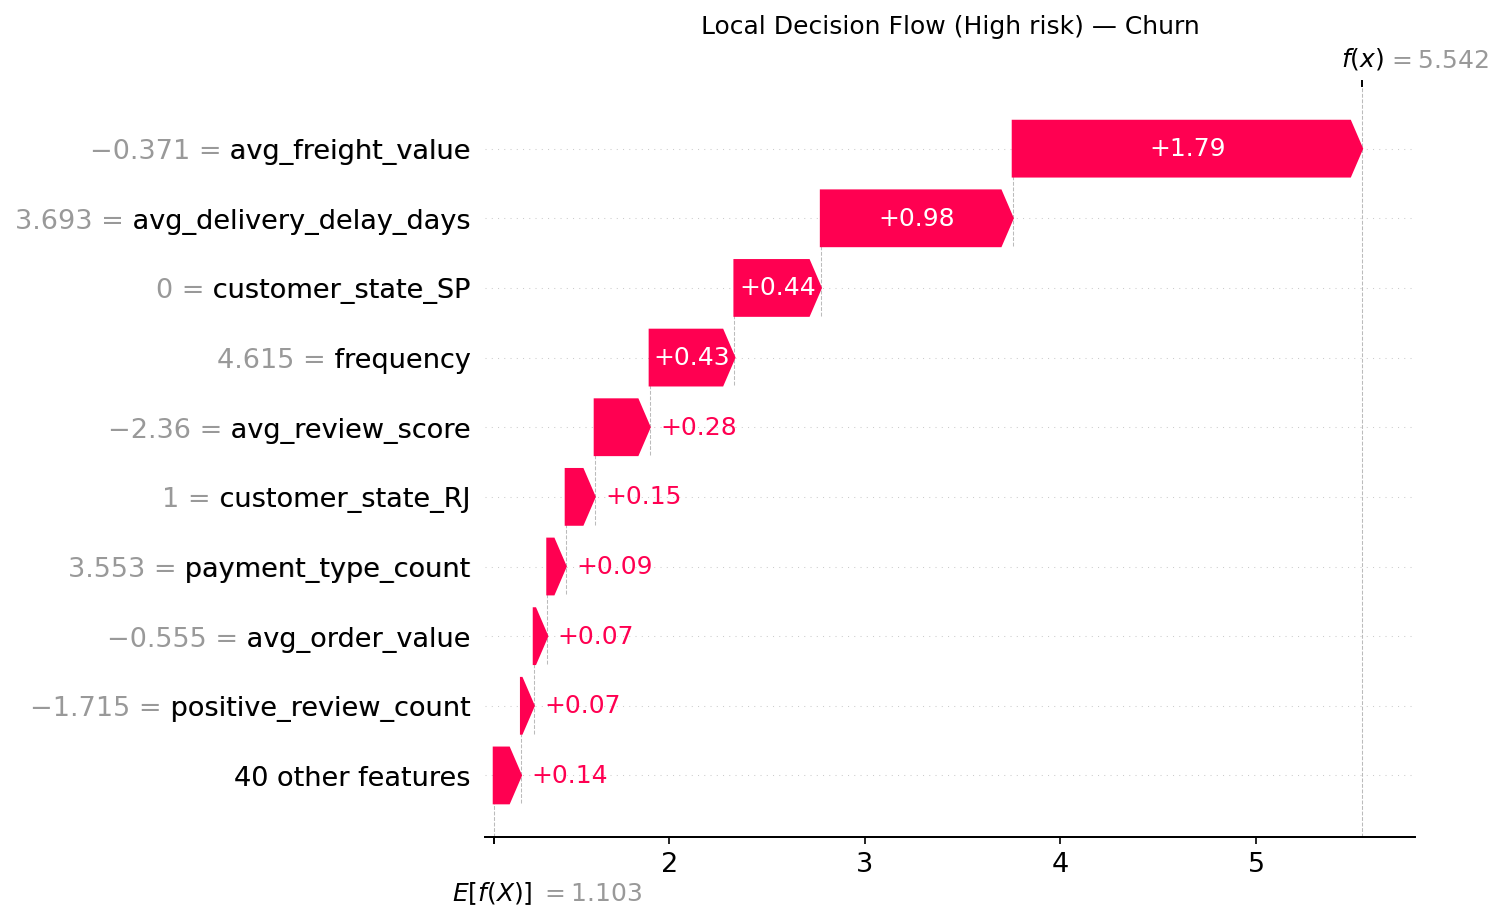

In [4]:
print("=== Low Churn Risk Case Waterfall ===")
display(Image(filename=str(FIGURES_DIR / 'shap_churn_local_low_risk.png')))

print("=== Borderline Churn Risk Case Waterfall ===")
display(Image(filename=str(FIGURES_DIR / 'shap_churn_local_borderline_risk.png')))

print("=== High Churn Risk Case Waterfall ===")
display(Image(filename=str(FIGURES_DIR / 'shap_churn_local_high_risk.png')))

## 🔍 Analysis: CLV Model Drivers (Random Forest)
We inspect the global beeswarm plot to understand predicted CLV drivers.

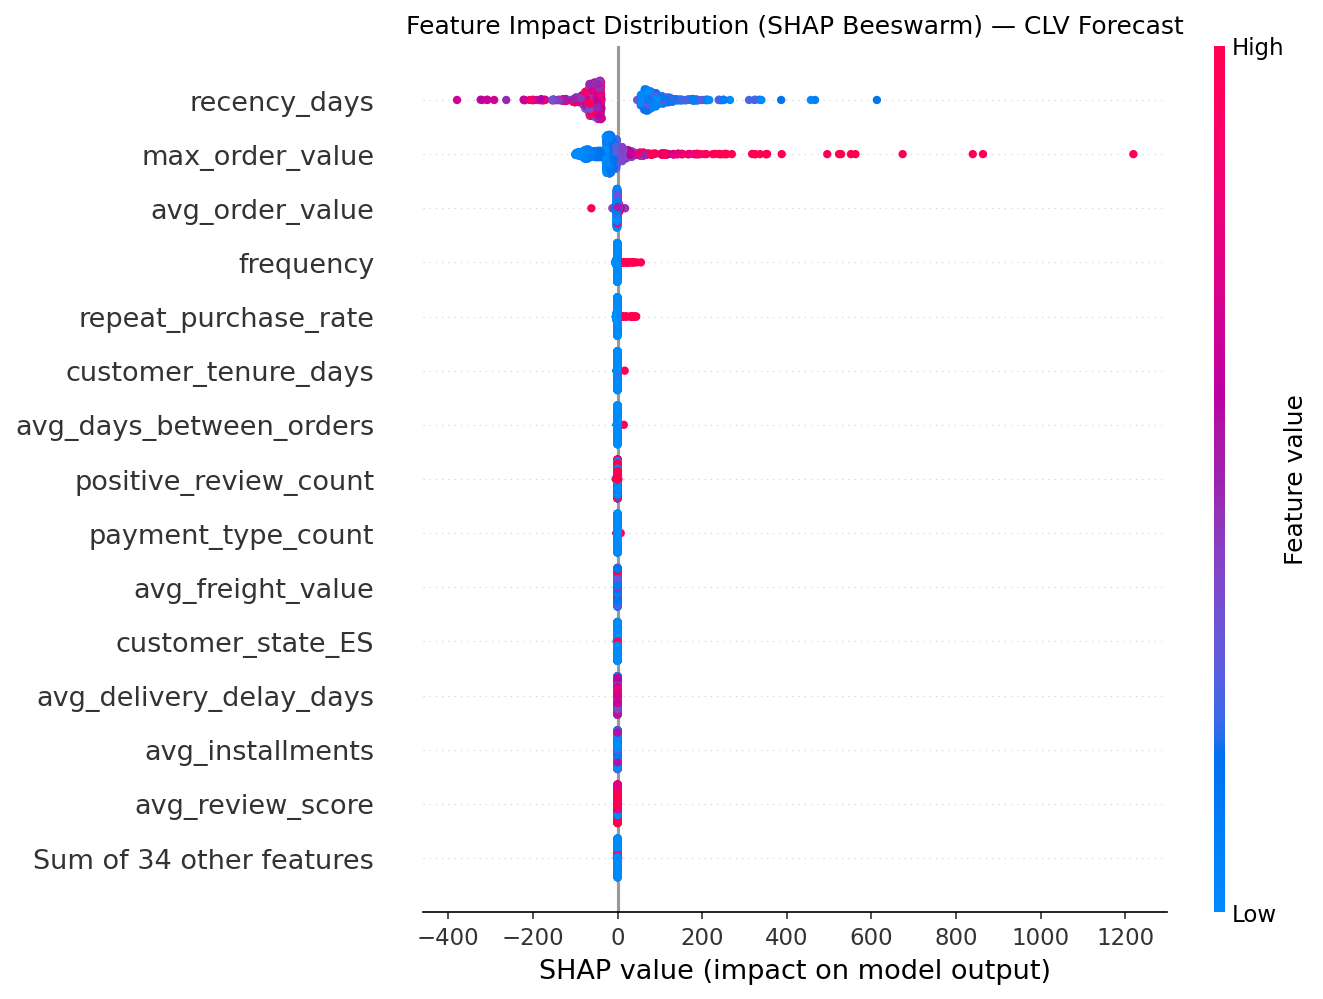

In [5]:
# Display Global CLV Beeswarm Plot
display(Image(filename=str(FIGURES_DIR / 'shap_clv_beeswarm.png')))

### CLV Local Waterfall Case Studies
Let's look at low, median, and high predicted CLV customer waterfalls.

=== Low CLV Case Waterfall ===


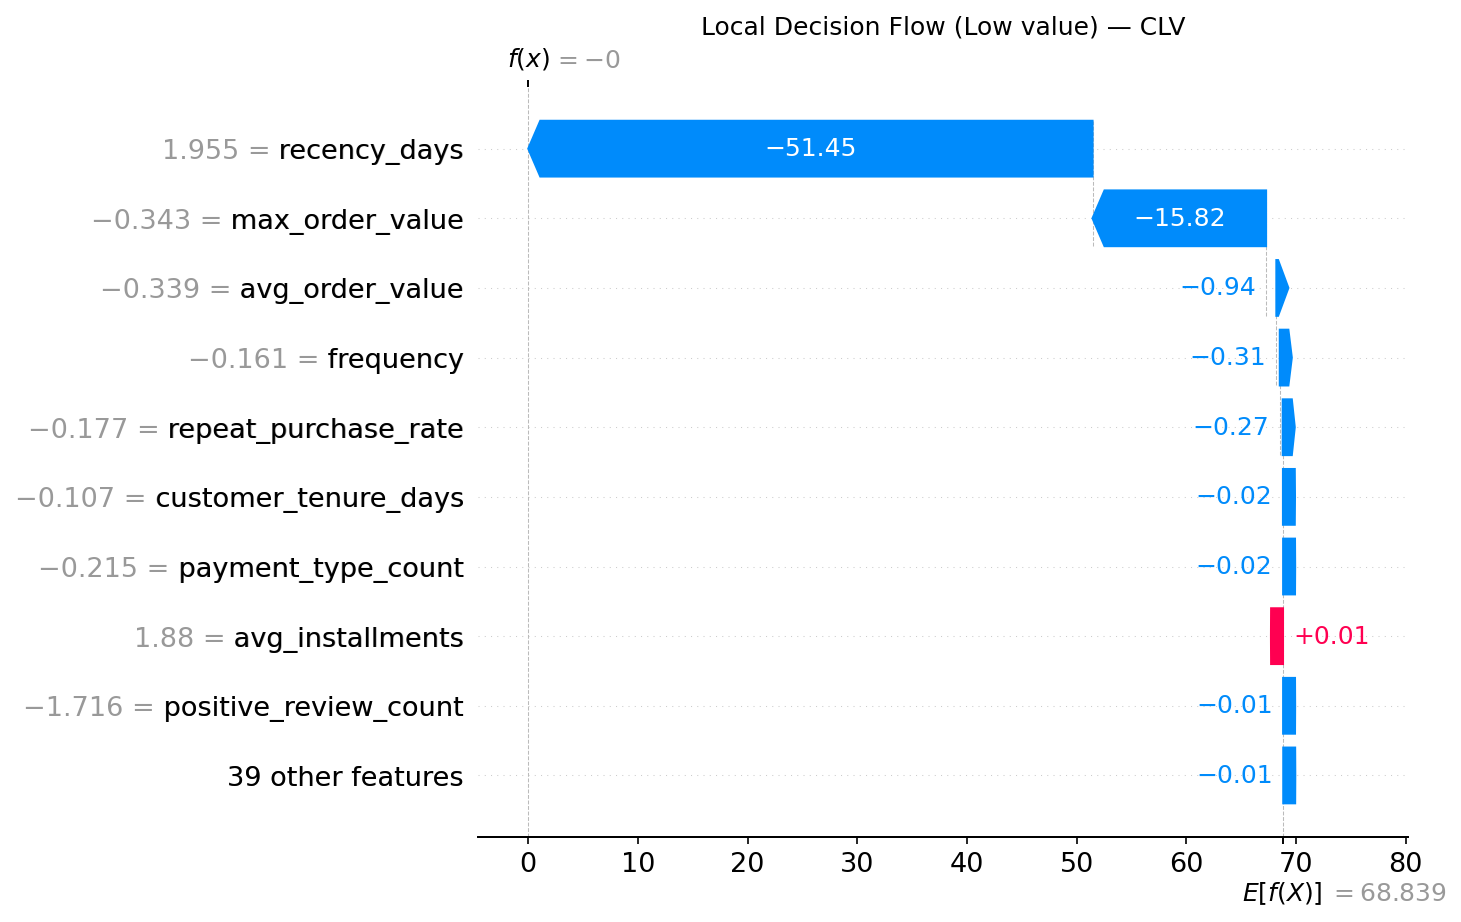

=== Median CLV Case Waterfall ===


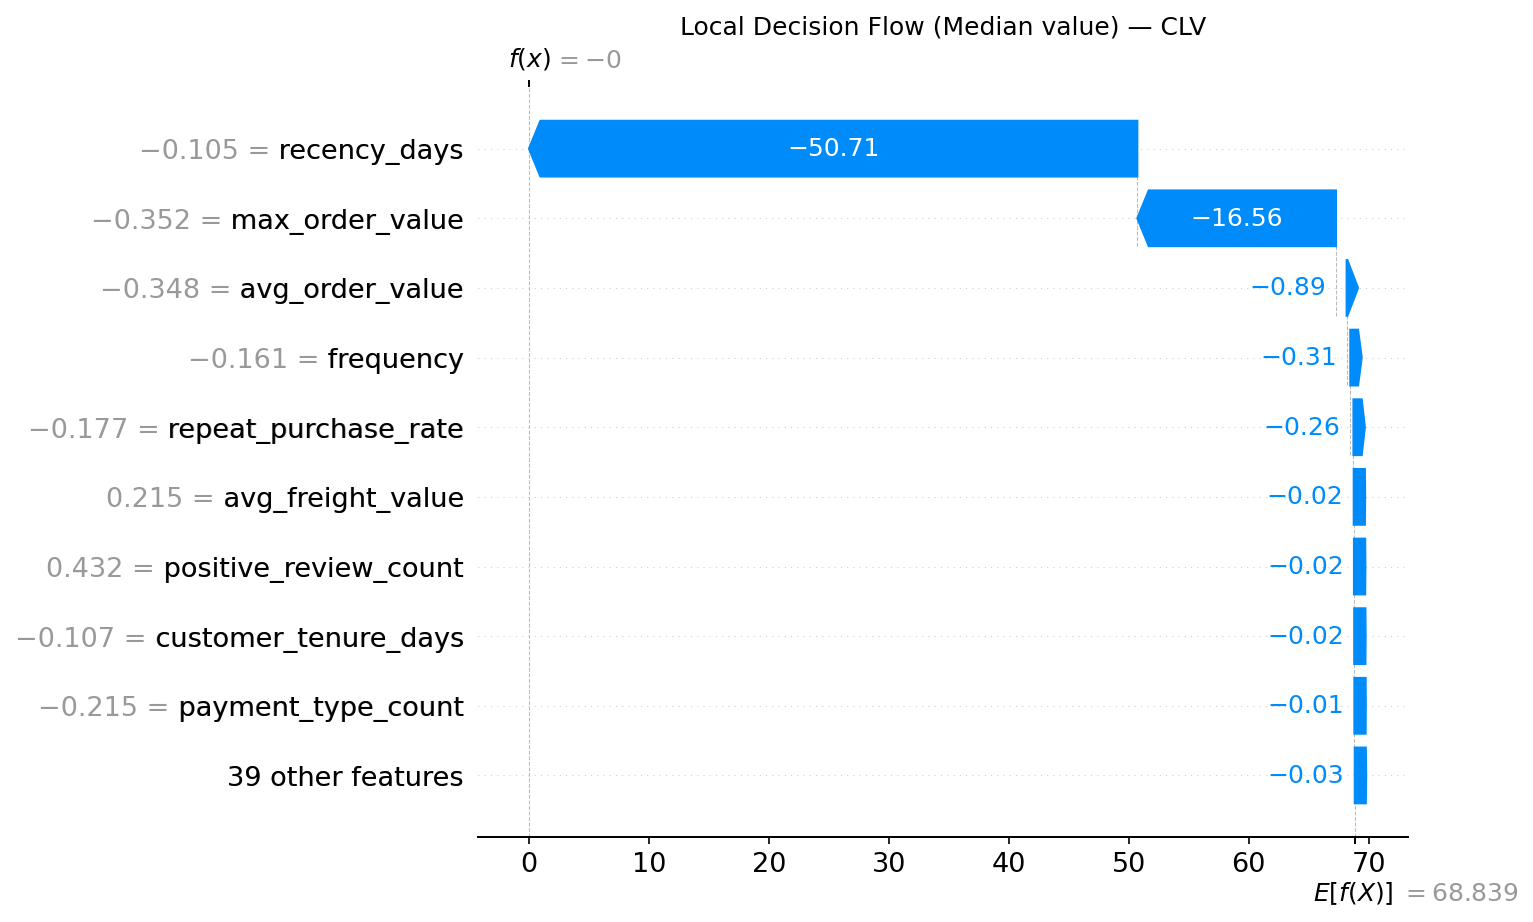

=== High CLV Case Waterfall ===


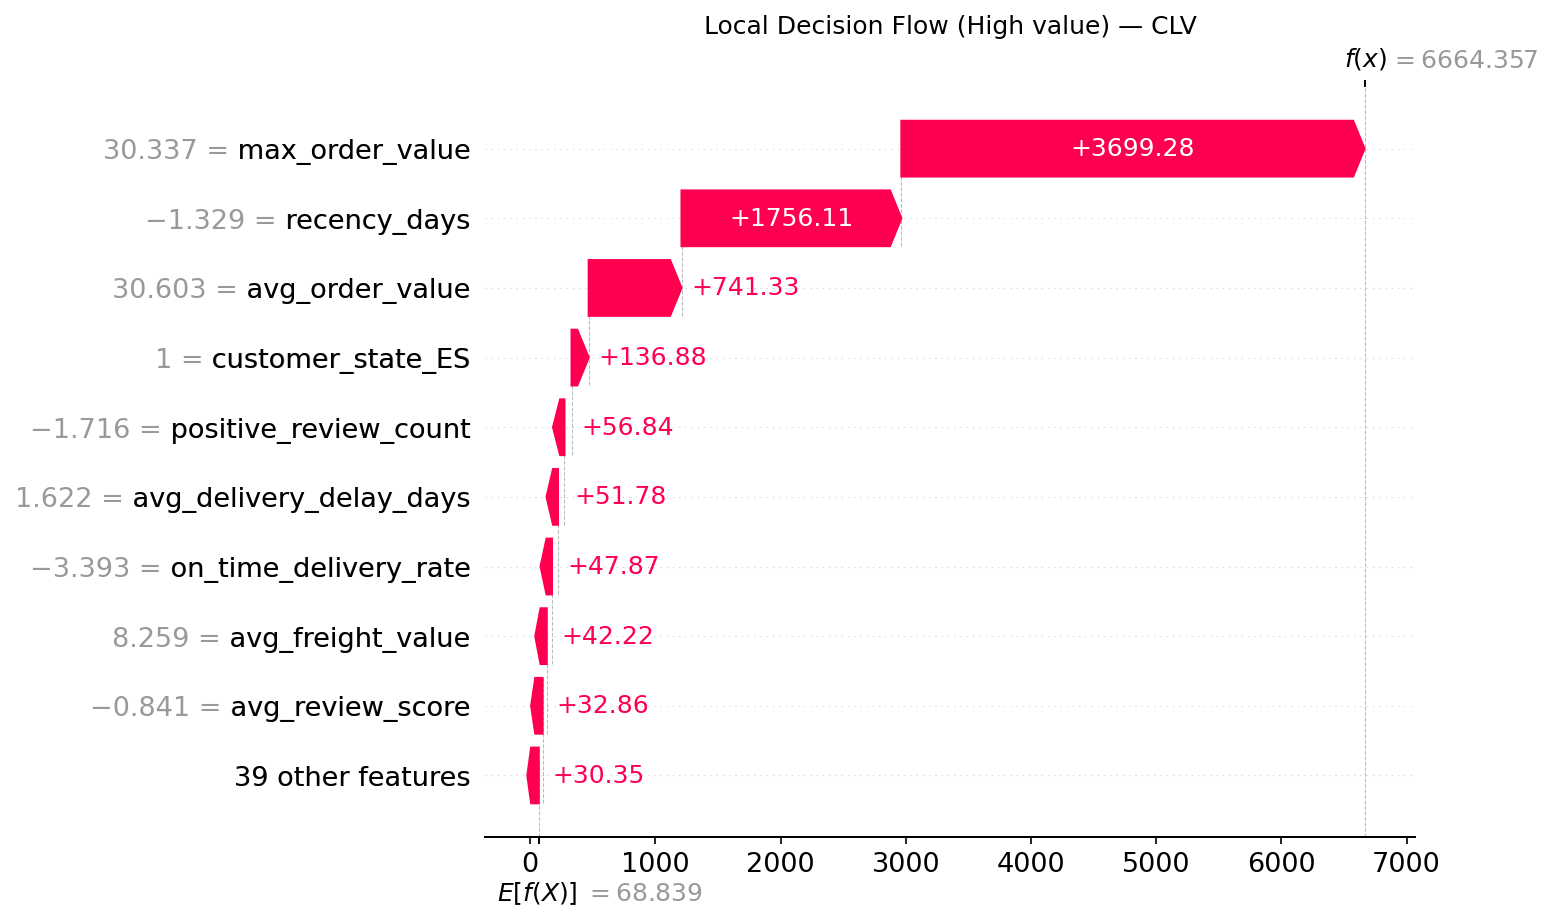

In [6]:
print("=== Low CLV Case Waterfall ===")
display(Image(filename=str(FIGURES_DIR / 'shap_clv_local_low_value.png')))

print("=== Median CLV Case Waterfall ===")
display(Image(filename=str(FIGURES_DIR / 'shap_clv_local_median_value.png')))

print("=== High CLV Case Waterfall ===")
display(Image(filename=str(FIGURES_DIR / 'shap_clv_local_high_value.png')))

## 💡 Business Interpretation
- **Churn Drivers:** The strongest driver is `customer_tenure_days`. A low tenure pushes the risk higher. Experiential metrics like review score and operational metrics like delivery delays act as strong boosters of risk when bad.
- **CLV Drivers:** `recency_days` and past monetization bounds (`avg_order_value`) are the primary features driving future spend predictions, representing the logical boundaries of our static dataset.

## ✅ Key Findings Summary
- **Global alignment:** Customer tenure and operational delays dominate churn risk. Recency and transaction sizes drive CLV.
- **Individual accountability:** Waterfall plots show the exact feature contribution pushing any customer's score away from the population average.

## 🚀 Business Recommendations
- **Prioritize Retention Loops:** Target shoppers with low tenure and low review scores immediately, as their SHAP values show a high risk build-up.
- **Operational recovery:** Use waterfall diagrams in customer service panels so agents can see the exact cause of friction (e.g. delivery delays) and address it.

## 📁 Outputs Generated
- Unified report: `reports/feature_importance_report.md`
- Global SHAP plots: `reports/figures/shap_churn_beeswarm.png`, `reports/figures/shap_clv_beeswarm.png`
- Local waterfalls: `reports/figures/shap_churn_local_*.png`, `reports/figures/shap_clv_local_*.png`